# FEATURE EXTRACTION AND VISUALIZATION

This notebook extracts HRV features from ECG signals and visualizes them
for different conditions (baseline, stress, amusement, meditation).

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
sys.path.append('..')
warnings.filterwarnings('ignore')

# Import your classes
from src.data import Data
from src.features import Features
from src.visualization import Visualization

# Initialize classes
data_loader = Data(fs=700)
feature_extractor = Features(fs=700)
viz = Visualization()
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Label mappings and colors (defined once here so all cells can use them)
label_names = {
    0: "Transition/Unknown",
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation"
}

label_colors = {
    1: "green",
    2: "red",
    3: "blue",
    4: "orange"
}

## 1. Load data

In [15]:
print("="*60)
print("2. LOADING DATA")
print("="*60)

# Load a single subject
pkl_path = "../data/WESAD/data/S2.pkl"
ecg, label = data_loader.read_subject(pkl_path)

print(f"✅ Loaded subject: S2")
print(f"   ECG shape: {ecg.shape}")
print(f"   Label shape: {label.shape}")
print(f"   Sampling frequency: {data_loader.fs} Hz")
print(f"   Total duration: {len(ecg)/data_loader.fs:.1f} seconds ({len(ecg)/data_loader.fs/60:.1f} minutes)")

2. LOADING DATA
✅ Loaded subject: S2
   ECG shape: (4255300,)
   Label shape: (4255300,)
   Sampling frequency: 700 Hz
   Total duration: 6079.0 seconds (101.3 minutes)


## 2. How to chunk the dataset? 

### 2.1 Just extract the labels from the big subject and then cut it to 30 sec

In [16]:
"""
2.1 APPROACH A — Filter ECG by label FIRST, then chunk.

For each label we:
  - extract only the samples belonging to that label (get_label_sub)
  - split those samples into 30s chunks (get_chunked_ecg)

This gives pure chunks but they come from concatenated
segments, not from the original time positions.
"""

pkl_path = "../data/WESAD/data/S2.pkl"
ecg, label = data_loader.read_subject(pkl_path)

label_names = {
    0: "Transition/Unknown",
    1: "Baseline",
    2: "Stress",
    3: "Amusement",
    4: "Meditation"
}

fs = data_loader.fs
CHUNK_SEC = 30
chunk_len = CHUNK_SEC * fs

print('='*72)
print('APPROACH A — Filter by label FIRST, then chunk')
print('='*72)

# Baseline: how many 30s chunks fit in the whole raw signal?
n_raw_chunks = len(ecg) // chunk_len
print(f'  Full raw signal: {n_raw_chunks} chunks of {CHUNK_SEC}s')
print()

# Per-label: filter then chunk
total_chunks_a = 0
print(f'  {"Label":<8} {"Samples":>10} {"Duration":>12} {"30s chunks":>10}  {"Pct of raw":>10}')
print(f'  {"─"*8} {"─"*10} {"─"*12} {"─"*10}  {"─"*10}')

for lbl in [0, 1, 2, 3, 4]:
    ecg_lbl = data_loader.get_label_sub(ecg, label, target_label=lbl)
    n_samples = len(ecg_lbl)
    if n_samples == 0:
        continue
    chunks = data_loader.get_chunked_ecg(ecg_lbl, time_in_sec=CHUNK_SEC)
    n_chunks = len(chunks)
    total_chunks_a += n_chunks
    dur = n_samples / fs
    pct = n_chunks / n_raw_chunks * 100
    name = label_names.get(lbl, f'L{lbl}')
    print(f'  L{lbl:<3} ({name:<18}) {n_samples:>8,}  {dur:>8.1f}s  {n_chunks:>6}     {pct:>5.1f}%')

print(f'  {"─"*60}')
print(f'  TOTAL (pure chunks from filtered signals): {total_chunks_a:>3}')
print(f'  (vs {n_raw_chunks} chunks from the raw signal)')

APPROACH A — Filter by label FIRST, then chunk
  Full raw signal: 202 chunks of 30s

  Label       Samples     Duration 30s chunks  Pct of raw
  ──────── ────────── ──────────── ──────────  ──────────
  L0   (Transition/Unknown) 2,142,701    3061.0s     102      50.5%
  L1   (Baseline          )  800,800    1144.0s      38      18.8%
  L2   (Stress            )  430,500     615.0s      20       9.9%
  L3   (Amusement         )  253,400     362.0s      12       5.9%
  L4   (Meditation        )  537,599     768.0s      25      12.4%
  ────────────────────────────────────────────────────────────
  TOTAL (pure chunks from filtered signals): 197
  (vs 202 chunks from the raw signal)


###  **Note** As we can see here that almost half of the data is transiation which is not useful in our case anyway

In [17]:
"""
2.1b APPROACH C — Chunk the full raw ECG FIRST, then keep only chunks
     where ≥90% of samples share the same label. Discard mixed chunks.

This preserves the original time positions (unlike Approach A which
concatenates filtered samples).
"""

THRESHOLD = 0.9
CHUNK_SEC = 30
chunk_len = CHUNK_SEC * data_loader.fs
n_raw_chunks = len(ecg) // chunk_len

chunks_clean, labels_clean, discarded = data_loader.get_majority_label_chunks(
    ecg, label, time_in_sec=CHUNK_SEC, threshold=THRESHOLD
)

print('='*72)
print(f'APPROACH C — Chunk raw signal first, keep only ≥{THRESHOLD*100:.0f}% pure')
print('='*72)
print(f'  Full raw signal: {n_raw_chunks} chunks of {CHUNK_SEC}s')
print(f'  Kept (≥{THRESHOLD*100:.0f}% pure):  {len(chunks_clean)}')
print(f'  Discarded (mixed): {discarded["count"]}')
print()

# Per-label: count chunks where this label was the dominant one
print(f'  {"Label":<8} {"Chunks kept":>12}  {"Pct of raw":>10}')
print(f'  {"─"*8} {"─"*12}  {"─"*10}')

for lbl in [0, 1, 2, 3, 4]:
    n_kept = sum(1 for l in labels_clean if l == lbl)
    if n_kept == 0:
        continue
    pct = n_kept / n_raw_chunks * 100
    name = label_names.get(lbl, f'L{lbl}')
    print(f'  L{lbl:<3} ({name:<18}) {n_kept:>6}          {pct:>5.1f}%')

print(f'  {"─"*35}')
print(f'  TOTAL (pure chunks at original positions): {len(chunks_clean):>3}')
print(f'  (vs {n_raw_chunks} chunks from the raw signal)')

if discarded['count'] > 0:
    print(f'\n  Discarded chunk purities: {[f"{p:.2f}" for p in discarded["purities"][:10]]}{"..." if len(discarded["purities"])>10 else ""}')

# ── Extract HRV features from these clean chunks ──
print('\n' + '-'*72)
print(f'EXTRACTING HRV FEATURES FROM CLEAN (≥{THRESHOLD*100:.0f}% PURE) CHUNKS')
print('-'*72)

features_clean_list = []
for i, (ecg_chunk, lbl) in enumerate(zip(chunks_clean, labels_clean)):
    feats = feature_extractor.get_hrv_features(ecg_chunk)
    feats['condition'] = label_names.get(lbl, f'Label {lbl}')
    feats['label']     = lbl
    feats['chunk_id']  = i
    features_clean_list.append(feats)

df_clean = pd.DataFrame(features_clean_list)
print(f'  ✅ Clean feature DataFrame shape: {df_clean.shape}')
print(f'  ✅ Columns: {list(df_clean.columns)}')

APPROACH C — Chunk raw signal first, keep only ≥90% pure
  Full raw signal: 202 chunks of 30s
  Kept (≥90% pure):  188
  Discarded (mixed): 14

  Label     Chunks kept  Pct of raw
  ──────── ────────────  ──────────
  L0   (Transition/Unknown)     95           47.0%
  L1   (Baseline          )     37           18.3%
  L2   (Stress            )     20            9.9%
  L3   (Amusement         )     11            5.4%
  L4   (Meditation        )     23           11.4%
  ───────────────────────────────────
  TOTAL (pure chunks at original positions): 188
  (vs 202 chunks from the raw signal)

  Discarded chunk purities: ['0.78', '0.65', '0.78', '0.72', '0.65', '0.52', '0.58', '0.62', '0.78', '0.85']...

------------------------------------------------------------------------
EXTRACTING HRV FEATURES FROM CLEAN (≥90% PURE) CHUNKS
------------------------------------------------------------------------
  ✅ Clean feature DataFrame shape: (188, 11)
  ✅ Columns: ['mean_rr', 'mean_hr', 'sdnn', '

## 3. FEATURE SUMMARY STATISTICS

In [18]:
print("\n" + "="*60)
print("3. FEATURE SUMMARY STATISTICS")
print("="*60)

# Feature columns
feature_cols = ['mean_rr', 'mean_hr', 'sdnn', 'rmssd', 'pnn50', 
                'lf_power', 'hf_power', 'lf_hf_ratio']

# Summary statistics by condition
summary_stats = df_clean.groupby('condition')[feature_cols].agg(['mean', 'std', 'count'])
display(summary_stats.round(3))


3. FEATURE SUMMARY STATISTICS


mean_rr               mean_hr                  sdnn  \
                       mean     std count    mean    std count     mean   
condition                                                                 
Amusement           903.257  41.575    11  67.013  3.169    11   74.607   
Baseline            829.802  31.842    37  72.892  3.102    37   62.783   
Label 6             849.622     NaN     1  70.894    NaN     1   53.495   
Label 7             896.234     NaN     1  69.389    NaN     1  132.922   
Meditation          894.143  37.953    23  67.609  2.940    23   66.817   
Stress              781.692  38.016    20  77.449  3.936    20   59.348   
Transition/Unknown  835.267  60.528    95  73.708  6.089    95   98.621   

                                    rmssd  ... pnn50 lf_power            \
                       std count     mean  ... count     mean std count   
condition                                  ...                            
Amusement           13.645    11   83.603  ...    11      NaN NaN     0   
Baseline            17.443    37   60.344  ...    37      NaN NaN     0   
Label 6                NaN     1   47.489  ...     1      NaN NaN     0   
Label 7                NaN     1  137.273  ...     1      NaN NaN     0   
Meditation          15.569    23   70.242  ...    23      NaN NaN     0   
Stress              21.167    20   47.132  ...    20      NaN NaN     0   
Transition/Unknown  78.777    95  109.572  ...    95      NaN NaN     0   

                   hf_power           lf_hf_ratio            
                       mean std count        mean std count  
condition                                                    
Amusement               NaN NaN     0         NaN NaN     0  
Baseline                NaN NaN     0         NaN NaN     0  
Label 6                 NaN NaN     0         NaN NaN     0  
Label 7                 NaN NaN     0         NaN NaN     0  
Meditation              NaN NaN     0         NaN NaN     0  
Stress                  NaN NaN     0         NaN NaN     0  
Transition/Unknown      NaN NaN     0         NaN NaN     0  

[7 rows x 24 columns]

## 4. VISUALIZE FEATURE DISTRIBUTIONS


4. FEATURE DISTRIBUTION PLOTS


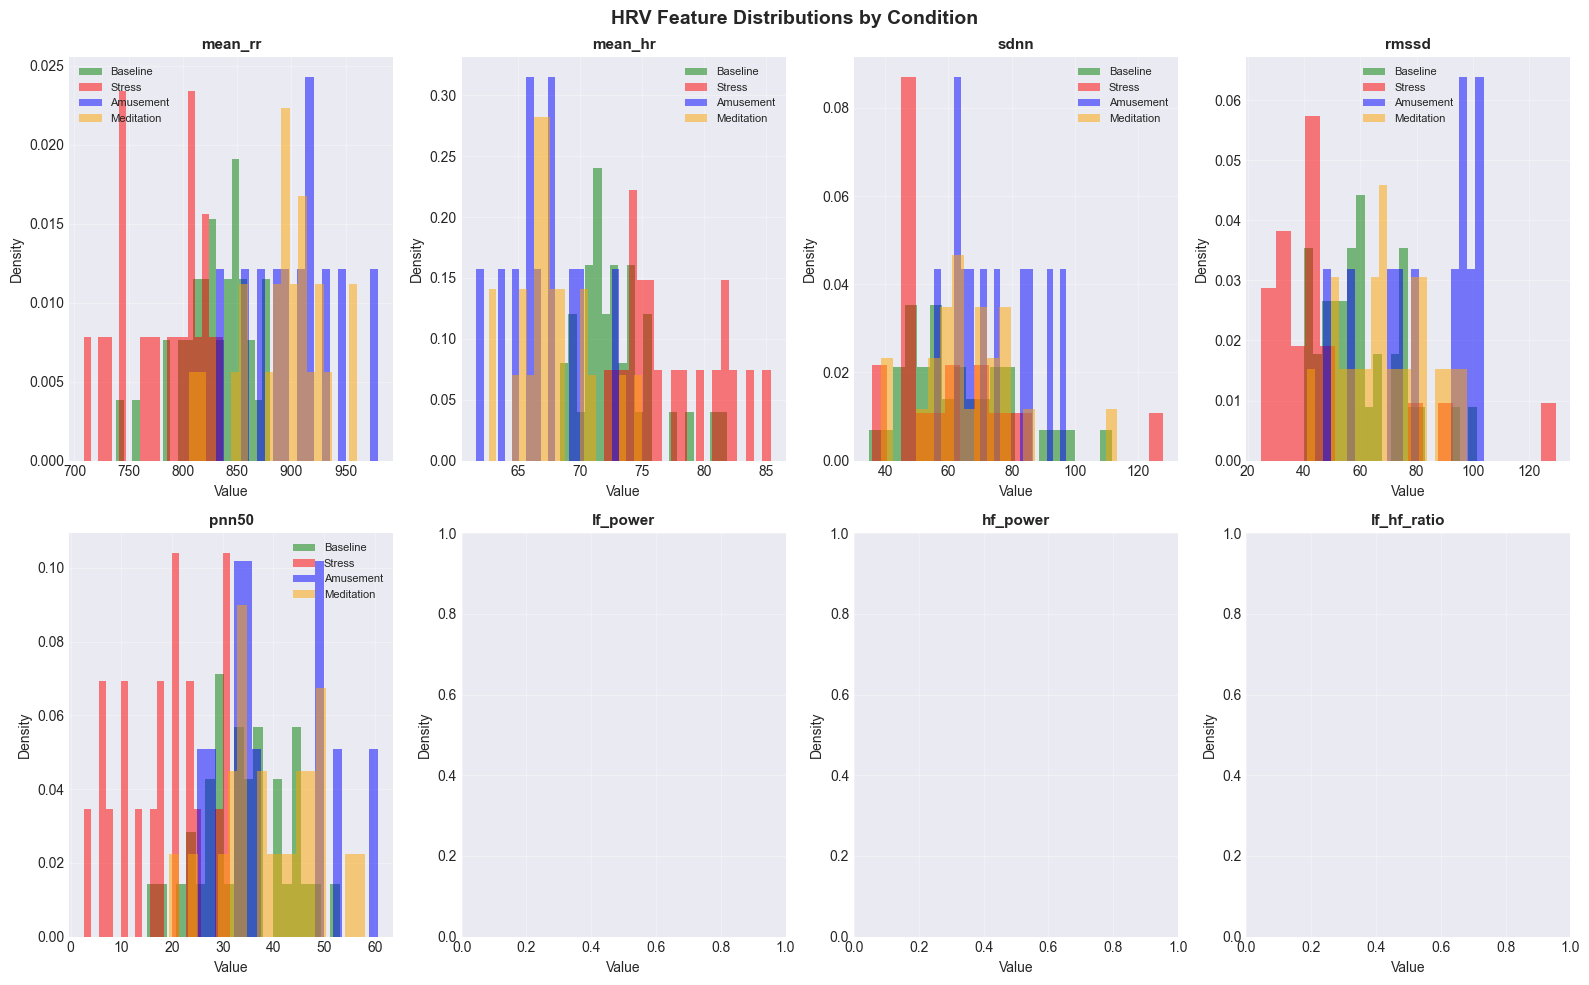

In [19]:
print("\n" + "="*60)
print("4. FEATURE DISTRIBUTION PLOTS")
print("="*60)

# Plot distributions for each feature
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    for label_id in [1, 2, 3, 4]:
        data = df_clean[df_clean['label'] == label_id][feature].dropna()
        if len(data) > 0:
            ax.hist(data, bins=20, alpha=0.5,
                    color=label_colors[label_id],
                    label=label_names[label_id],
                    density=True)
    
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('HRV Feature Distributions by Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. BOX PLOTS FOR EACH FEATURE


5. BOX PLOTS COMPARING CONDITIONS


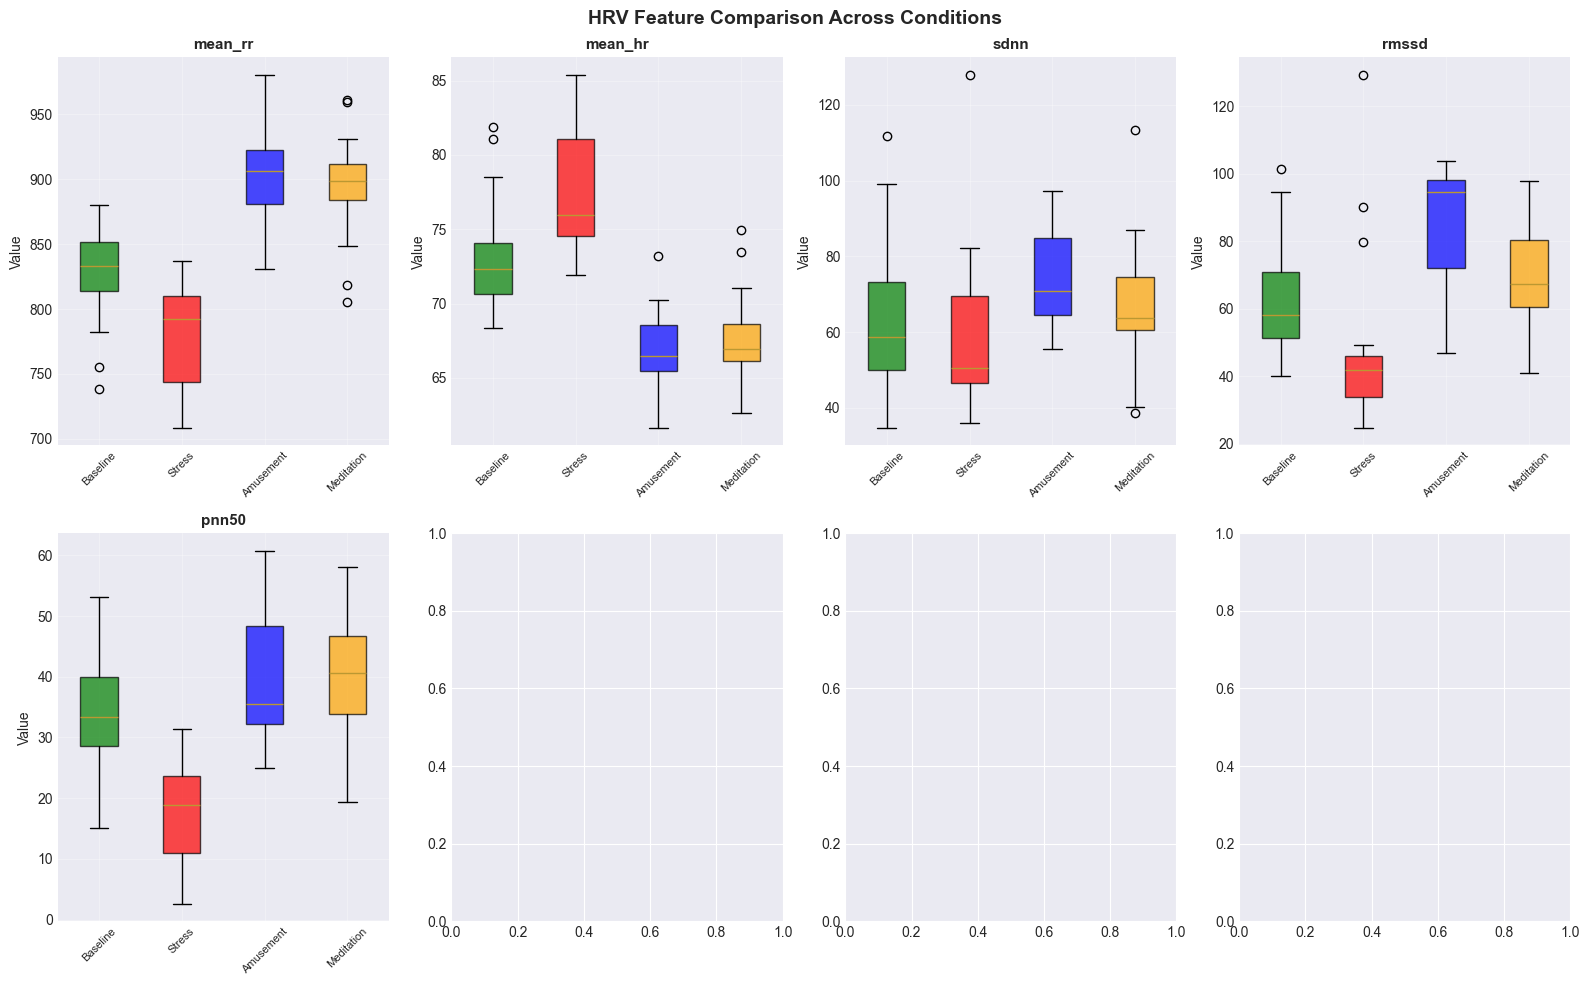

In [20]:
print("\n" + "="*60)
print("5. BOX PLOTS COMPARING CONDITIONS")
print("="*60)

# Create box plots for each feature
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    # Prepare data for box plot
    data_to_plot = []
    labels_to_plot = []
    
    for label_id in [1, 2, 3, 4]:
        label_df = df_clean[df_clean['label'] == label_id]
        if len(label_df) > 0:
            data = label_df[feature].dropna()
            if len(data) > 0:
                data_to_plot.append(data.values)  # Convert to array
                labels_to_plot.append(label_names[label_id])
    
    # Check if we have data to plot
    if len(data_to_plot) > 0:
        # Create box plot
        bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
        
        # Color the boxes
        for i, box in enumerate(bp['boxes']):
            if i < len(labels_to_plot):
                # Get the label_id for this box
                label_id = [1, 2, 3, 4][i]
                box.set_facecolor(label_colors[label_id])
                box.set_alpha(0.7)
        
        ax.set_title(feature, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('HRV Feature Comparison Across Conditions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. CORRELATION MATRIX

In [21]:
print("\n" + "="*60)
print("6. FEATURE CORRELATION MATRIX (Table Format)")
print("="*60)

def display_correlation_table(df, feature_cols, title):
    """
    Display correlation matrix as a styled table
    """
    corr_matrix = df[feature_cols].corr()
    
    # Style the table
    styled = corr_matrix.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1)
    styled = styled.format("{:.2f}")
    styled = styled.set_caption(title)
    styled = styled.set_properties(**{
        'font-size': '12px',
        'text-align': 'center'
    })
    
    # Add color coding for correlations
    def color_cells(val):
        if val > 0.7:
            return 'background-color: #2d7a3e; color: white; font-weight: bold'
        elif val > 0.4:
            return 'background-color: #90c695; color: black'
        elif val > -0.4:
            return 'background-color: #f5f5f5; color: black'
        elif val > -0.7:
            return 'background-color: #f4a460; color: black'
        else:
            return 'background-color: #c41e3a; color: white; font-weight: bold'
    
    styled = styled.applymap(color_cells)
    
    display(styled)
    return corr_matrix

# Display for each condition
for label_id in [1, 2, 3, 4]:
    label_df = df_clean[df_clean['label'] == label_id]
    if len(label_df) > 0:
        print(f"\n{label_names[label_id]}:")
        corr_matrix = display_correlation_table(
            label_df, 
            feature_cols,
            f'Feature Correlation Matrix - {label_names[label_id]}'
        )


6. FEATURE CORRELATION MATRIX (Table Format)

Baseline:


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-0.99,-0.39,-0.14,0.13,nan,nan,nan
mean_hr,-0.99,1.00,0.48,0.21,-0.11,nan,nan,nan
sdnn,-0.39,0.48,1.00,0.63,0.22,nan,nan,nan
rmssd,-0.14,0.21,0.63,1.00,0.55,nan,nan,nan
pnn50,0.13,-0.11,0.22,0.55,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan



Stress:


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-0.99,-0.15,-0.02,0.37,nan,nan,nan
mean_hr,-0.99,1.00,0.26,0.13,-0.33,nan,nan,nan
sdnn,-0.15,0.26,1.00,0.78,0.24,nan,nan,nan
rmssd,-0.02,0.13,0.78,1.00,0.37,nan,nan,nan
pnn50,0.37,-0.33,0.24,0.37,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan



Amusement:


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-1.00,-0.07,0.68,0.69,nan,nan,nan
mean_hr,-1.00,1.00,0.15,-0.69,-0.65,nan,nan,nan
sdnn,-0.07,0.15,1.00,0.14,0.34,nan,nan,nan
rmssd,0.68,-0.69,0.14,1.00,0.46,nan,nan,nan
pnn50,0.69,-0.65,0.34,0.46,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan



Meditation:


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
mean_rr,1.00,-1.00,0.25,0.34,0.15,nan,nan,nan
mean_hr,-1.00,1.00,-0.20,-0.34,-0.12,nan,nan,nan
sdnn,0.25,-0.20,1.00,0.37,0.78,nan,nan,nan
rmssd,0.34,-0.34,0.37,1.00,0.39,nan,nan,nan
pnn50,0.15,-0.12,0.78,0.39,1.00,nan,nan,nan
lf_power,nan,nan,nan,nan,nan,nan,nan,nan
hf_power,nan,nan,nan,nan,nan,nan,nan,nan
lf_hf_ratio,nan,nan,nan,nan,nan,nan,nan,nan


## 7. FEATURE COMPARISON: STRESS VS BASELINE


7. STRESS VS BASELINE COMPARISON


,Feature,Baseline Mean,Stress Mean,Fold Change,p-value,Significant
0,mean_rr,829.8023,781.6924,0.9420,0.0000,True
1,mean_hr,72.8919,77.4489,1.0625,0.0000,True
2,sdnn,62.7826,59.3475,0.9453,0.5133,False
3,rmssd,60.3445,47.1322,0.7811,0.0149,True
4,pnn50,34.0939,18.0717,0.5301,0.0000,True
5,lf_power,NaN,NaN,NaN,NaN,False
6,hf_power,NaN,NaN,NaN,NaN,False
7,lf_hf_ratio,NaN,NaN,NaN,NaN,False


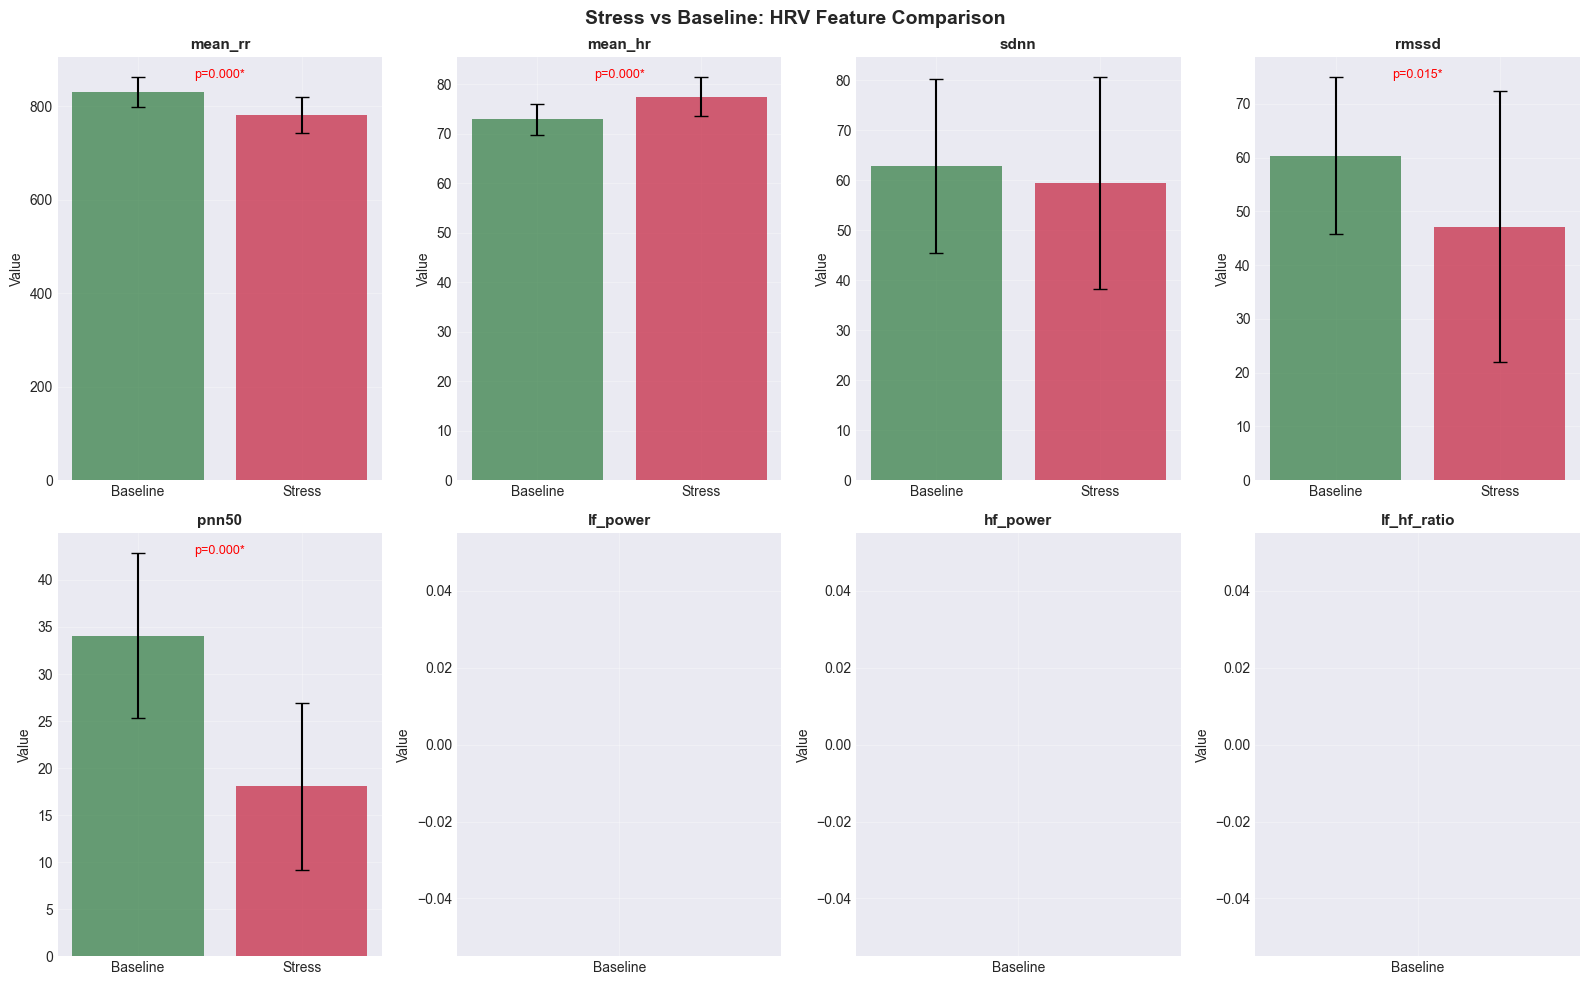

In [22]:
print("\n" + "="*60)
print("7. STRESS VS BASELINE COMPARISON")
print("="*60)

# Compare stress (label 2) vs baseline (label 1) using df_clean
stress_df = df_clean[df_clean['label'] == 2]
baseline_df = df_clean[df_clean['label'] == 1]

if len(stress_df) > 0 and len(baseline_df) > 0:
    comparison_data = []
    
    for feature in feature_cols:
        baseline_mean = baseline_df[feature].mean()
        stress_mean = stress_df[feature].mean()
        
        # Calculate fold change
        fold_change = stress_mean / baseline_mean if baseline_mean != 0 else np.nan
        
        # Statistical test
        from scipy.stats import ttest_ind
        baseline_vals = baseline_df[feature].dropna()
        stress_vals = stress_df[feature].dropna()
        
        if len(baseline_vals) > 1 and len(stress_vals) > 1:
            t_stat, p_value = ttest_ind(baseline_vals, stress_vals)
        else:
            t_stat, p_value = np.nan, np.nan
        
        comparison_data.append({
            'Feature': feature,
            'Baseline Mean': baseline_mean,
            'Stress Mean': stress_mean,
            'Fold Change': fold_change,
            'p-value': p_value,
            'Significant': p_value < 0.05 if not np.isnan(p_value) else False
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df.round(4))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 4, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(feature_cols):
        ax = axes[idx]
        
        # Get data
        baseline_vals = baseline_df[feature].dropna()
        stress_vals = stress_df[feature].dropna()
        
        # Create bar plot
        ax.bar(['Baseline', 'Stress'], 
              [baseline_vals.mean(), stress_vals.mean()],
              color=['#2d7a3e', '#c41e3a'], alpha=0.7)
        
        # Add error bars (std)
        ax.errorbar(['Baseline', 'Stress'], 
                   [baseline_vals.mean(), stress_vals.mean()],
                   yerr=[baseline_vals.std(), stress_vals.std()],
                   fmt='none', color='black', capsize=5)
        
        ax.set_title(feature, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
        
        # Add p-value if significant
        p_val = comparison_df[comparison_df['Feature'] == feature]['p-value'].values[0]
        if not np.isnan(p_val) and p_val < 0.05:
            ax.text(0.5, 0.95, f'p={p_val:.3f}*', transform=ax.transAxes,
                   ha='center', fontsize=9, color='red')
    
    plt.suptitle('Stress vs Baseline: HRV Feature Comparison', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. RADAR PLOT FOR FEATURE COMPARISON


8. RADAR PLOT - Feature Profile Comparison


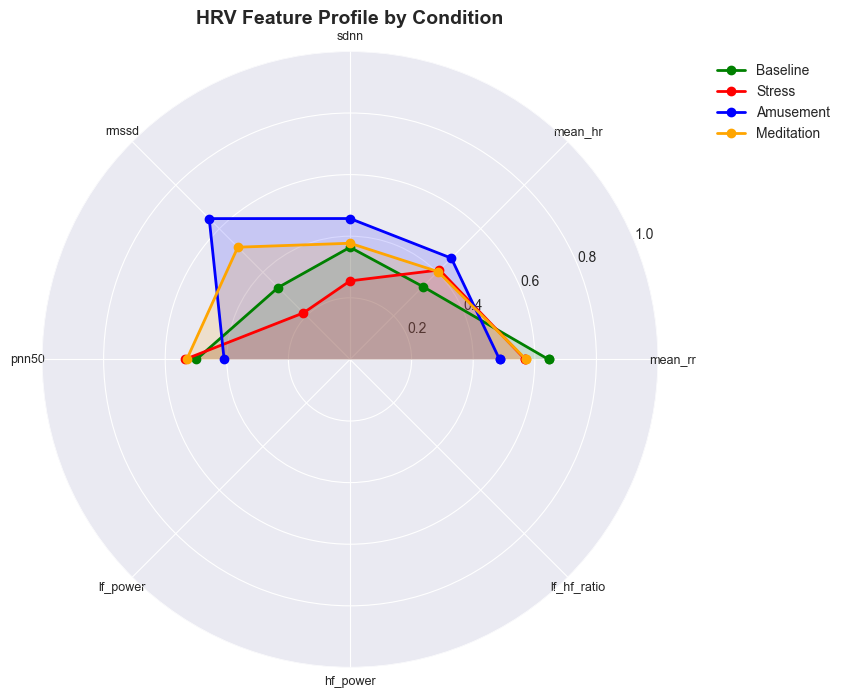

In [23]:
print("\n" + "="*60)
print("8. RADAR PLOT - Feature Profile Comparison")
print("="*60)

# Normalize features for radar plot
def normalize_features(df, feature_cols):
    """Normalize features to 0-1 range"""
    normalized = df[feature_cols].copy()
    for col in feature_cols:
        min_val = normalized[col].min()
        max_val = normalized[col].max()
        if max_val > min_val:
            normalized[col] = (normalized[col] - min_val) / (max_val - min_val)
    return normalized

# Get normalized features for each condition
normalized_features = {}
for label_id in [1, 2, 3, 4]:
    label_df = df_clean[df_clean['label'] == label_id]
    if len(label_df) > 0:
        df_norm = normalize_features(label_df, feature_cols)
        normalized_features[label_id] = df_norm.mean()

# Create radar plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

# Number of features
N = len(feature_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

for label_id in [1, 2, 3, 4]:
    if label_id in normalized_features:
        values = [normalized_features[label_id][feature] for feature in feature_cols]
        values += values[:1]  # Close the loop
        
        ax.plot(angles, values, 'o-', linewidth=2, 
                color=label_colors[label_id], label=label_names[label_id])
        ax.fill(angles, values, alpha=0.15, color=label_colors[label_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_cols, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('HRV Feature Profile by Condition', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)
plt.show()

## 9. PAIR PLOT FOR TOP FEATURES


9. PAIR PLOT - Top Feature Relationships
Top 4 discriminative features: ['mean_hr', 'sdnn', 'mean_rr', 'rmssd']
Color palette: {'Baseline': 'green', 'Stress': 'red', 'Amusement': 'blue', 'Meditation': 'orange'}


KeyError: 'Transition/Unknown'

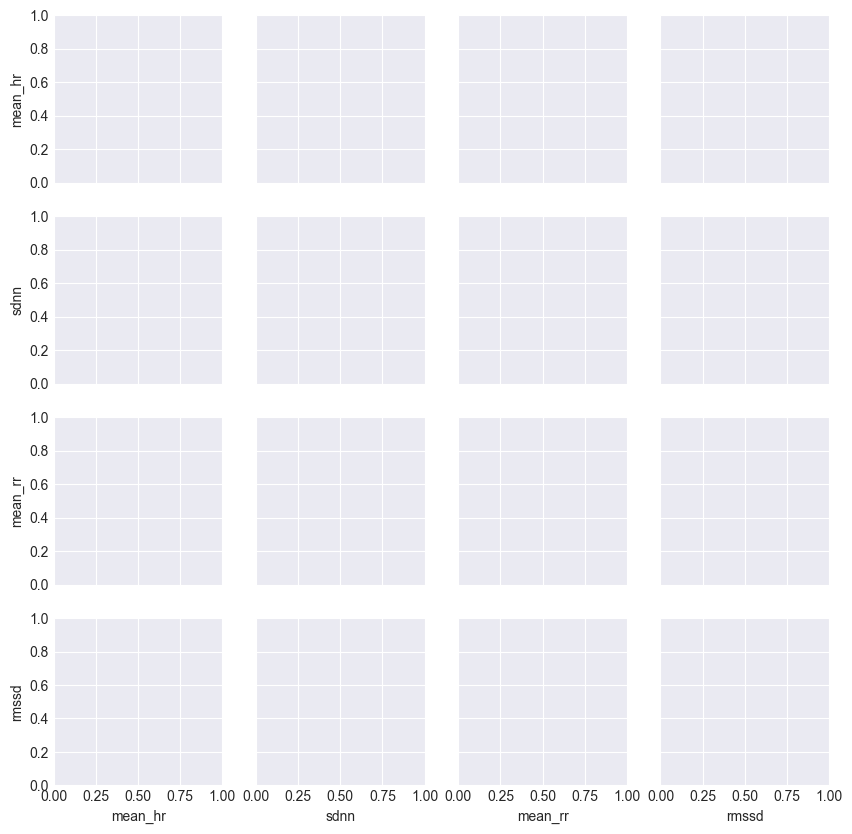

In [24]:
print("\n" + "="*60)
print("9. PAIR PLOT - Top Feature Relationships")
print("="*60)

# Select top 4 most discriminative features
if len(stress_df) > 0 and len(baseline_df) > 0:
    # Find most discriminative features (largest fold change)
    top_features = comparison_df.nlargest(4, 'Fold Change')['Feature'].tolist()
    
    print(f"Top 4 discriminative features: {top_features}")
    
    # Prepare data for pair plot
    pair_data = df_clean[top_features + ['condition']].copy()
    
    # Create a color palette dictionary with condition names as keys
    color_palette = {label_names[label_id]: label_colors[label_id] 
                     for label_id in [1, 2, 3, 4] 
                     if len(df_clean[df_clean['label'] == label_id]) > 0}
    
    print(f"Color palette: {color_palette}")
    
    # Create pair plot with correct palette
    g = sns.pairplot(pair_data, 
                     vars=top_features, 
                     hue='condition', 
                     palette=color_palette,  # Now using condition names
                     diag_kind='kde',
                     plot_kws={'alpha': 0.5, 's': 40},
                     diag_kws={'fill': True})
    
    g.fig.suptitle('Pair Plot of Top Discriminative Features', 
                   fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 10. SAVE RESULTS

In [ ]:
"""
Save df_clean and summary results to CSV files.
"""
import os

output_dir = "../results/features"
os.makedirs(output_dir, exist_ok=True)

# Save the complete flat df_clean DataFrame
df_clean.to_csv(os.path.join(output_dir, "all_features.csv"), index=False)
print(f"Saved: all_features.csv  (shape: {df_clean.shape})")

# Save per-condition CSVs
for label_id in [1, 2, 3, 4]:
    label_df = df_clean[df_clean['label'] == label_id]
    if len(label_df) > 0:
        fname = f"features_{label_names[label_id].replace(' ', '_').replace('/', '_')}.csv"
        label_df.to_csv(os.path.join(output_dir, fname), index=False)
        print(f"Saved: {fname}")

print(f"\nAll features saved to: {output_dir}")

## SUMMARY

In [ ]:
print("\n" + "="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)

# stress_df and baseline_df are defined in cell 7; guard if cell hasn run yet
stress_df   = df_clean[df_clean['label'] == 2]
baseline_df = df_clean[df_clean['label'] == 1]

print(f"\nExtracted features from {len(df_clean)} ECG chunks")
print(f"Features: {', '.join(feature_cols)}")
conditions_present = [label_names[i] for i in [1, 2, 3, 4] if len(df_clean[df_clean['label'] == i]) > 0]
print(f"Conditions analyzed: {', '.join(conditions_present)}")

print("\nKey Observations:")
for feature in feature_cols:
    if len(stress_df) > 0 and len(baseline_df) > 0:
        baseline_mean = baseline_df[feature].mean()
        stress_mean = stress_df[feature].mean()
        fold_change = stress_mean / baseline_mean if baseline_mean != 0 else np.nan
        print(f"  * {feature}: Stress {'up' if fold_change > 1 else 'down'} {abs(fold_change):.2f}x vs Baseline")

print("\nFeature extraction and visualization complete!")